In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [57]:
df= pd.read_excel('Boston_Housing.xlsx', sheet_name='Data')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [58]:
RM=df[['RM']]
MEDV=df['MEDV']

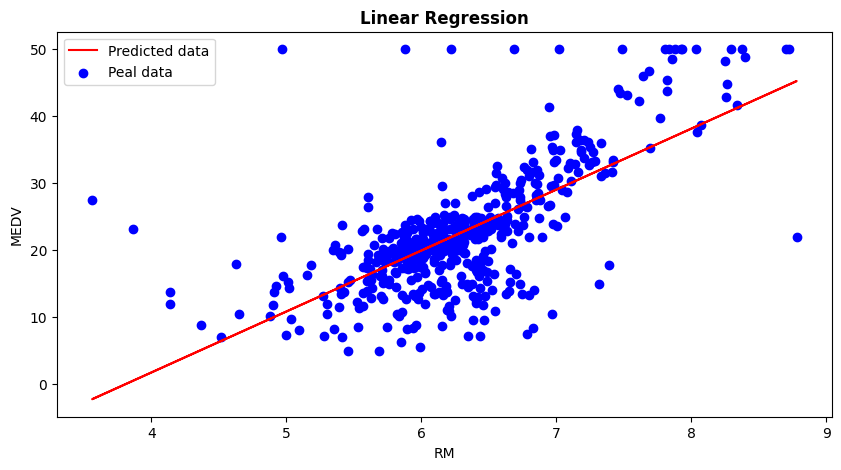

Linear Regression Equation:
MEDV=9.10*RM-34.67


In [59]:
#Q1-1
model1=LinearRegression()
model1.fit(RM,MEDV)
MEDV_predict1=model1.predict(RM)
plt.figure(figsize=(10,5))
intercept = model1.intercept_
coefficient = model1.coef_[0]
plt.plot(RM,MEDV_predict1,color='red',label='Predicted data')
plt.scatter(RM,MEDV,color='blue',label='Peal data')
plt.title('Linear Regression',fontweight='bold')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.legend()
plt.show()

print('Linear Regression Equation:')
print(f'MEDV={coefficient:.2f}*RM{intercept:.2f}')

In [60]:
#Q1-2
features1=df.drop('MEDV',axis=1)
model2=LinearRegression()
model2.fit(features1,MEDV)
MEDV_predict2=model2.predict(features1)
MSE=mean_squared_error(MEDV,MEDV_predict2)
RMSE=np.sqrt(MSE)
R2=r2_score(MEDV,MEDV_predict2)
print('R2:',R2)
print('RSME:',RMSE)

R2: 0.7406426641094095
RSME: 4.679191295697281


In [61]:
#Q1-3
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X = sm.add_constant(X)

features2 = list(X.columns)
pmax = 1

while (len(features2) > 0):
    p_values = []
    X_current = X[features2]
    model = sm.OLS(y, X_current).fit()
    p_values = model.pvalues

    max_p = max(p_values)

    if max_p > 0.05:
        redundant_feature = p_values.idxmax()
        features2.remove(redundant_feature)
    else:
        break

final_model = sm.OLS(y, X[features2]).fit()
print("Features with P<0.05")
print(final_model.pvalues)

Features with P<0.05
const      2.727265e-12
CRIM       1.010438e-03
ZN         7.542759e-04
CHAS       1.551469e-03
NOX        1.209413e-06
RM         2.889779e-19
DIS        6.837043e-15
RAD        2.996799e-06
TAX        5.214237e-04
PTRATIO    9.235063e-13
B          5.565743e-04
LSTAT      2.140586e-25
dtype: float64


#Q1-4
1.In order to comparing 3 models we made, we should consider R^2 component:
Model 1 : 0.484
Model 2 : 0.741
Model 3 : 0.741
Consequently, 2nd and 3rd model are better

2.Eliminating "INDUS" and "AGE" features had not any impact on model's efficiency and the R^2 model retained constant.

3.ّFor declaring most efficient features we should mention those which have lower P-value and higher coefficient.
"LSTAT" and "RM" have most impact with P-value near zero and coefficient -0.50 and 3.49, respectively.

mean prices for each cluster
Cluster
0    38000.0
2    24000.0
1    18000.0
3    12000.0
Name: MEDV, dtype: float64


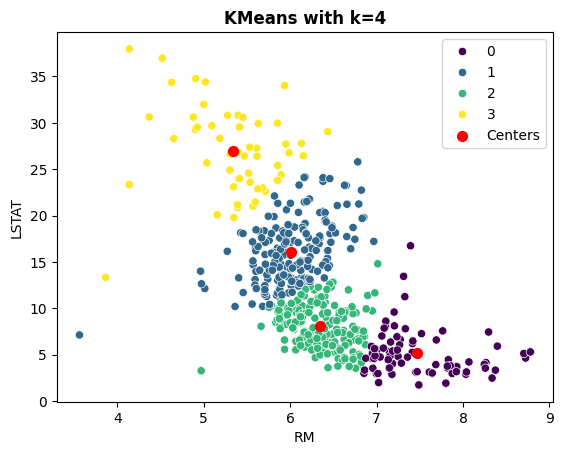

In [62]:
#Q2 & Q3-1
features3=df[['RM','LSTAT']]

scaler=StandardScaler()
features3=scaler.fit_transform(features3)

kmeans=KMeans(n_clusters=4,random_state=42, n_init=15)
cluster=kmeans.fit_predict(features3)

df["Cluster"]=cluster
mean_cluster=df.groupby("Cluster")["MEDV"].mean().sort_values(ascending=False)
print("mean prices for each cluster")
print(mean_cluster.round(0)*1000)

sns.scatterplot(x='RM', y='LSTAT', hue='Cluster', data=df, palette='viridis')
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c="red", marker=".", s=200, label="Centers")
plt.xlabel("RM")
plt.ylabel("LSTAT")
plt.title("KMeans with k=4",fontweight="bold")
plt.legend()
plt.show()

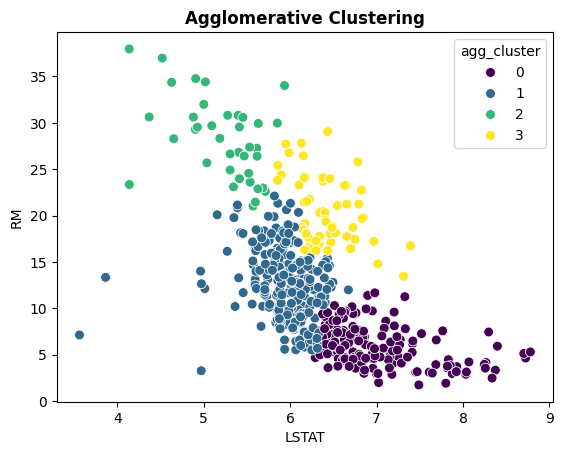

Agglomerative MEDV clustering
agg_cluster
0    31750.0
1    20170.0
3    14320.0
2    12340.0
Name: MEDV, dtype: float64


In [63]:
#Q3-2
features4=df[['RM', 'LSTAT']]

scaler=StandardScaler()
features4=scaler.fit_transform(features4)

agg_clustering=AgglomerativeClustering(n_clusters=4)
agg_labels=agg_clustering.fit_predict(features4)

df['agg_cluster']=agg_labels
mean_agg=df.groupby('agg_cluster')['MEDV'].mean().sort_values(ascending=False)

sns.scatterplot(x='RM', y='LSTAT', hue='agg_cluster', data=df, palette='viridis',s=50)
plt.title('Agglomerative Clustering',fontweight="bold")
plt.xlabel('LSTAT')
plt.ylabel('RM')
plt.show()

print("Agglomerative MEDV clustering")
print(mean_agg.round(2)*1000)

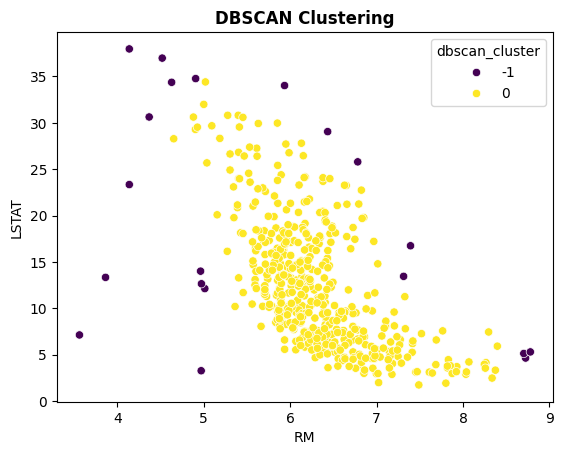

DBSCAN MEDV clustering
dbscan_cluster
 0    22630.0
-1    20240.0
Name: MEDV, dtype: float64


In [64]:
#Q3-3
features5=df[['RM', 'LSTAT']]

scaler = StandardScaler()
features5=scaler.fit_transform(features5)

dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels=dbscan.fit_predict(features5)

df['dbscan_cluster'] = dbscan_labels
dbscan_mean=df.groupby('dbscan_cluster')['MEDV'].mean().sort_values(ascending=False)

sns.scatterplot(x='RM', y='LSTAT', hue='dbscan_cluster', data=df, palette='viridis')
plt.title('DBSCAN Clustering',fontweight='bold')
plt.xlabel('RM')
plt.ylabel('LSTAT')
plt.show()

print("DBSCAN MEDV clustering")
print(dbscan_mean.round(2)*1000)

#Q3-4

Clustering Methods:
1.Centroid-based(e.g., Kmeans)
2.Density-based(e.g., DBSCAN)
3.Heirarchical(e.g., Agglomorative)
4.Distribution-based(e.g., GMM)

Agglomorative and Kmeans work better than DBSCAN